In [1]:
!pip install -U datasets transformers accelerate evaluate fsspec


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Preprocesamiento de los Datos

Dataset: https://huggingface.co/datasets/jonathan-roberts1/EuroSAT.

Este dataset es usado para clasificar el uso y la cobertura del suelo. Este dataset se base en imágenes satelitales sentinel-2 cubriendo 13 bandas espectrales y consiste en 10 clases con un total de 27k labels e imágenes geo-referenciadas con dimensiones de *64x64*.


In [2]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
import evaluate

metric = evaluate.load("accuracy")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
%%capture
!sudo apt -qq install git-lfs
!git config --global credential.helper store

In [5]:
from datasets import load_dataset
dataset = load_dataset("jonathan-roberts1/EuroSAT")


README.md:   0%|          | 0.00/2.37k [00:00<?, ?B/s]

(…)-00000-of-00001-26e80b6de2d4dca7.parquet:   0%|          | 0.00/88.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27000 [00:00<?, ? examples/s]

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 27000
    })
})

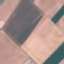

In [9]:
sample = dataset["train"][20]

sample["image"]

In [10]:
features = dataset["train"].features
label_names = features['label'].names
print(f"features labels names: {label_names}")
print(f"len: {len(label_names)}")

features labels names: ['annual crop', 'forest', 'herbaceous vegetation', 'highway', 'industrial', 'pasture', 'permanent crop', 'residential', 'river', 'sea or lake']
len: 10


In [11]:
print(f"Dimensions for this image: {sample['image'].height}x{sample['image'].width}")
print(f"features labels fot this image: {sample['label']}")

Dimensions for this image: 64x64
features labels fot this image: 0


Los labels para este dataset por defecto viene codificados en enteros. Se procede a crear un diccionario que contenga la versión string para observar a que corresponde cada entero.

In [12]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    id2label[i] = label
id2label

{0: 'annual crop',
 1: 'forest',
 2: 'herbaceous vegetation',
 3: 'highway',
 4: 'industrial',
 5: 'pasture',
 6: 'permanent crop',
 7: 'residential',
 8: 'river',
 9: 'sea or lake'}

A continuación, se realiza la modificación de las dimensiones de la imagen y la normalización de los colors usando la media y la desviación estandar. Tambíen se puede pensar en un data augmentation para mejorar el dataset de training y proporcionar mayor variablidad en el mismo, esto podría ayudar al modelo a ser mas robusto y obtener un buen rendimiento.

Para realizar las transformaciones en las imágenes, se puede usar la clase `AutoImageProcessor` que permite preparar los input features para el modelo elegido.

In [13]:
from transformers import AutoImageProcessor
model_checkpoint = "microsoft/swin-tiny-patch4-window7-224"
image_processor  = AutoImageProcessor.from_pretrained(model_checkpoint)
batch_size = 34
image_processor


preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


ViTImageProcessor {
  "do_convert_rgb": null,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

Ahora se añade dos funciones para procesamiento de las imágenes una para entrenamiendo donde se incluye tambiéon data augmentation y otra para validación que solo incluye, redimensión, corte al centro y normalización. Estas funciones esperan como argumento un batch de imágenes donde se aplica la transformación.

In [14]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)

normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
#getting size
if "height" in image_processor.size:
    size = (image_processor.size["height"], image_processor.size["width"])
    crop_size = size
    max_size = None
elif "shortest_edge" in image_processor.size:
    size = image_processor.size["shortest_edge"]
    crop_size = (size, size)
    max_size = image_processor.size.get('longest_edge')

#data augmentation
train_transforms = Compose([
    RandomResizedCrop(crop_size),
    RandomHorizontalFlip(),
    ToTensor(),
    normalize,
])
val_transform = Compose([
    Resize(size),
    CenterCrop(crop_size),
    ToTensor(),
    normalize
])

def preprocess_train(example_batch):
    example_batch["pixel_values"] = [
        train_transforms(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch

def preprocess_val(example_batch):
    example_batch["pixel_values"] = [
        val_transform(image.convert("RGB")) for image in example_batch["image"]
    ]
    return example_batch



Ahora se realiza el split del dataset para pasarlo a las funciones de preprocess, se usa un helper llamado ```set_transform``` que aplica las funciones de preprocesamiento ```preprocess_train``` y ```preprocess_train``` solo cuando las imágenes son cargadas en la RAM



In [15]:
splits = dataset["train"].train_test_split(test_size=0.1)
train_ds = splits["train"]
val_ds = splits["test"]

train_ds.set_transform(preprocess_train)
val_ds.set_transform(preprocess_val)

In [31]:
dir(dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__enter__',
 '__eq__',
 '__exit__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_values_features',
 '_check_values_type',
 'align_labels_with_mapping',
 'cache_files',
 'cast',
 'cast_column',
 'class_encode_column',
 'cleanup_cache_files',
 'clear',
 'column_names',
 'copy',
 'data',
 'filter',
 'flatten',
 'flatten_indices',
 'formatted_as',
 'from_csv',
 'from_json',
 'from_parquet',
 'from_text',
 'fromkeys',
 'get',
 'items',
 'keys',
 'load_from_disk',
 'map',
 'num_columns',
 'num_r

In [28]:
train_ds


Dataset({
    features: ['image', 'label'],
    num_rows: 24300
})

In [29]:
val_ds

Dataset({
    features: ['image', 'label'],
    num_rows: 2700
})

### Entrenamiento del modelo
Se procede a descargar el modelo y hacer fine-tune del mismo. Para la clasificación se usa la clase `AutoModelForImageClassification`, usando el método `from_pretained` que descargará el modelo y el cache de sus pesos aprendidos.


In [18]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer

#download model and cache the weights
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Some weights of SwinForImageClassification were not initialized from the model checkpoint at microsoft/swin-tiny-patch4-window7-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([10]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([10, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Para inicar el trainer, primero se debe añadir las configuraciones de entrenamiento respectivas para configurar el entrenamiento y la métrica de evaluación.

In [19]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"{model_name}-finetuned-eurosat",
    remove_unused_columns=False,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    gradient_accumulation_steps=4,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=3,
    warmup_ratio=0.1,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=True,
)

Se crea una función para calcular las métricas de cada predicción

In [20]:
import numpy as np

def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)

In [21]:
import torch

def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [22]:
trainer = Trainer(
    model,
    args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
)

<ipython-input-22-f220d94b5868>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [23]:
train_results = trainer.train()
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: juliansalas080 (juliansalas080-xprende) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy
1,0.218700,0.111584,0.963704
2,0.176800,0.064479,0.980000
3,0.132500,0.053099,0.982593


Uploading...:   0%|          | 0.00/110M [00:00<?, ?B/s]

***** train metrics *****
  epoch                    =          3.0
  total_flos               = 1687935228GF
  train_loss               =       0.2899
  train_runtime            =   0:06:20.11
  train_samples_per_second =      191.786
  train_steps_per_second   =        1.413


In [24]:
metrics = trainer.evaluate()

trainer.log_metrics("eval", metrics)
trainer.save_metrics("eval", metrics)

***** eval metrics *****
  epoch                   =        3.0
  eval_accuracy           =     0.9826
  eval_loss               =     0.0531
  eval_runtime            = 0:00:06.49
  eval_samples_per_second =    415.799
  eval_steps_per_second   =      12.32


In [25]:
trainer.push_to_hub()

Uploading...:   0%|          | 0.00/110M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/juliansalas080/swin-tiny-patch4-window7-224-finetuned-eurosat/commit/d3ff9c9af16db381cf7d5e05c0aff67e386f5840', commit_message='End of training', commit_description='', oid='d3ff9c9af16db381cf7d5e05c0aff67e386f5840', pr_url=None, repo_url=RepoUrl('https://huggingface.co/juliansalas080/swin-tiny-patch4-window7-224-finetuned-eurosat', endpoint='https://huggingface.co', repo_type='model', repo_id='juliansalas080/swin-tiny-patch4-window7-224-finetuned-eurosat'), pr_revision=None, pr_num=None)

### Inferencia

Se carga una imágen de un bosque `(clase forest)` no visto en el euroSAT dataset, para ver como el modelo hace la inferencia

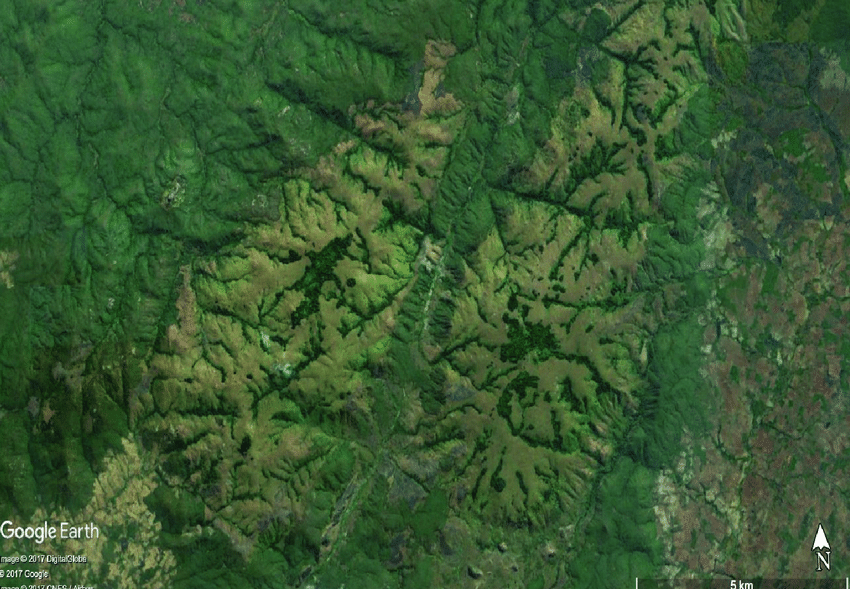

In [32]:
from PIL import Image
import requests

url = 'https://huggingface.co/nielsr/convnext-tiny-finetuned-eurostat/resolve/main/forest.png'
image = Image.open(requests.get(url, stream=True).raw)
image

In [33]:
from transformers import AutoModelForImageClassification, AutoImageProcessor

repo_name = "juliansalas080/swin-tiny-patch4-window7-224-finetuned-eurosat"

image_processor = AutoImageProcessor.from_pretrained(repo_name)
model = AutoModelForImageClassification.from_pretrained(repo_name)

preprocessor_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.16k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

In [42]:
# prepare image for the model
encoding = image_processor(image.convert("RGB"), return_tensors="pt")
print(encoding.pixel_values.shape)

torch.Size([1, 3, 224, 224])


In [44]:
encoding

{'pixel_values': tensor([[[[-1.2445, -1.1932, -1.2788,  ..., -1.6042, -1.5870, -1.5699],
          [-1.2445, -1.1932, -1.2103,  ..., -1.6042, -1.6213, -1.5699],
          [-1.2959, -1.1589, -1.2103,  ..., -1.5699, -1.5699, -1.5699],
          ...,
          [-1.3130, -1.4158, -1.5528,  ..., -1.1932, -1.0904, -0.0287],
          [-1.3987, -1.4500, -1.6555,  ..., -1.1075, -1.1589,  0.0741],
          [-0.6452, -0.2171, -0.5424,  ..., -1.2274, -1.0904,  0.0912]],

         [[-0.1800, -0.1625, -0.2850,  ..., -0.8102, -0.7752, -0.7577],
          [-0.2150, -0.1800, -0.1800,  ..., -0.8277, -0.8452, -0.7402],
          [-0.2675, -0.1625, -0.1975,  ..., -0.7752, -0.7577, -0.7577],
          ...,
          [-0.4251, -0.5476, -0.6702,  ..., -0.8627, -0.7052,  0.5028],
          [-0.5476, -0.6176, -0.8803,  ..., -0.7927, -0.7577,  0.6254],
          [-0.1275,  0.3803,  0.1001,  ..., -0.9503, -0.7752,  0.6254]],

         [[-0.8633, -0.8284, -0.8807,  ..., -1.2467, -1.2293, -1.1944],
          [-0

In [35]:
import torch

with torch.no_grad():
    outputs = model(**encoding)
    logits = outputs.logits

In [50]:
logits

tensor([[-0.8291,  2.1733,  1.1119, -0.5290, -0.4310,  3.2828,  0.2035,  0.4563,
         -1.9426, -1.7226]])

In [53]:
predicted_class_idx = logits.argmax(-1).item()
print(predicted_class_idx)
print("Predicted class:", model.config.id2label[predicted_class_idx])

5
Predicted class: pasture


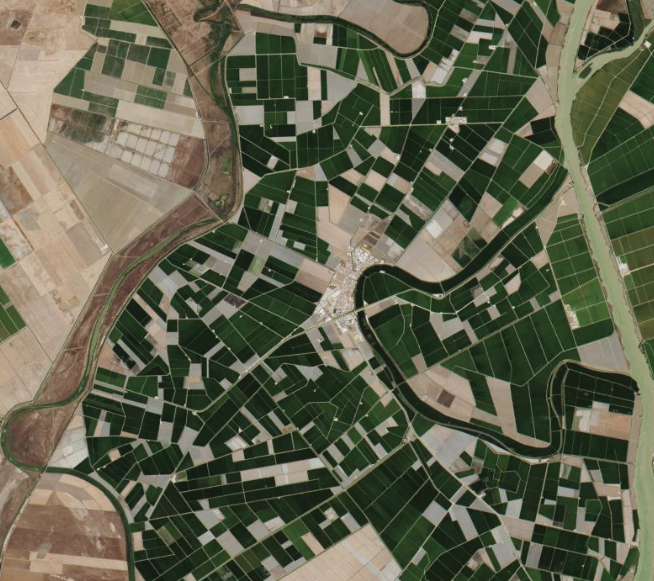

In [63]:
from PIL import Image


image = Image.open("./test1.png")

image


In [65]:
encoding = image_processor(image.convert("RGB"), return_tensors="pt")
print(encoding.pixel_values.shape)

torch.Size([1, 3, 224, 224])


In [66]:
import torch

with torch.no_grad():
    outputs = model(**encoding)
    logits = outputs.logits

In [68]:
logits

tensor([[ 0.4339, -1.6647, -1.2634, -0.2068,  0.5811, -0.1620,  0.8052,  0.3765,
          1.2161,  0.1321]])

In [70]:
predicted_class_idx = logits.argmax(-1).item()
print(predicted_class_idx)
print("Predicted class:", model.config.id2label[predicted_class_idx])

8
Predicted class: river


### Tarea: Fine-tuning de un modelo Vision Transformer

1)

El modelo selecionado para el ejercicio de fine-tune es `microsoft/swin-tiny-patch4-window7-224`. Y el dataset selecionado es el `EuroSAT` basado en imágenes satelitales con 10 clases y 27k etiquetas e imágenes geo-referenciadas.




2)

- Swin transformer es un modelo entrenado en `ImageNet-1k` con imágenes de resolución 224x224. Este modelo es un tipo de visíon transformer de `feature maps` jerárquicas juntando los parches en las imágenes. Se escogió este modelo por su propósito de uso general para clasificación y reconocimiento, además al ser una versión `tinny` ofrece una balance entre eficiencia y performance, al ser entrenado con un dataset bastante grande como lo es  `ImageNet-1K ` provee extracción de características bastante fuertes y variabilidad que podrá hacer más sencillo el fine-tune y alcanzar el objetivo de clasificación de esta tarea con mayor facilidad mientras no exige hardware de computo bastante alto.

- El proceso de fine-tunning se realizó eliminando la head final que contenia el modelo incial de 1000 clases y se añadió las 10 clases que contiene el dataset `EuroSAT`, entonces se remplazó la ultima capa con la capa que buscaba clasificar las 10 clases del dataset. Así durante el entrenamiento se utlizó los pesos ya aprendidos para extraer fuertes características del dataset y permitir adaptar el modelo a la nueva tarea de clasificación. Es importante comentar que los nuevos pesos de la tarea se inician de manera aleatorea hasta alcanzar un buen accurracy que es la métrica que se uso para esta tarea.


En este caso, la predicción no fue la correcta ya que el modelo predijo la clase `pasture`, pareciera que el modelo aprendió texturas, tonos y contexto que es considerado como un pasto en lugar de `forest`.


Esto podría suceder por el tipo de dataset al ser solo mosáicos de RGB y no tipo de banda NIR  mas especializado en finos detalles para distinguir entre vegetación y pasto.